In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

RANDOM_STATE = 20
SAMPLE_FRACTION = 0.25
N_SPLITS = 5
SCORING = ['accuracy', 'f1_weighted']
np.random.seed(RANDOM_STATE)

In [ ]:
rt_iot2022 = fetch_ucirepo(id=942)
X_full = rt_iot2022.data.features
y_full = rt_iot2022.data.targets
target_col = y_full.columns[0]

if SAMPLE_FRACTION < 1.0:
    X = X_full.sample(frac=SAMPLE_FRACTION, random_state=RANDOM_STATE)
    y = y_full.loc[X.index, target_col]
else:
    X = X_full.copy()
    y = y_full[target_col].copy()

print(f'Using {len(X)} rows, {X.shape[1]} features. Target: {target_col}')
print('Class distribution (sample):')
print(y.value_counts().head())

Using 30779 rows, 83 features. Target: Attack_type
Class distribution (sample):
Attack_type
DOS_SYN_Hping     23782
Thing_Speak        2009
ARP_poisioning     1924
MQTT_Publish       1027
NMAP_UDP_SCAN       622
Name: count, dtype: int64


In [ ]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]

preprocess = ColumnTransformer(
    [
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    ]
)

print(f'Numeric features: {len(numeric_cols)} | Categorical features: {len(categorical_cols)}')

Numeric features: 81 | Categorical features: 2


In [ ]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=400, solver='lbfgs', n_jobs=-1),
    'RandomForest': RandomForestClassifier(n_estimators=120, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=150, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE),
    'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
    'GradientBoosting': GradientBoostingClassifier(random_state=RANDOM_STATE),
    'LinearSVM': LinearSVC(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [ ]:
results = []
reports = []

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model)])

    cv_pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    report_text = classification_report(y, cv_pred, digits=3)
    reports.append({'model': name, 'report': report_text})

    scores = cross_validate(
        pipe, X, y, cv=cv, scoring=SCORING, n_jobs=-1, return_train_score=False
    )

    results.append({
        'model': name,
        'mean_accuracy': scores['test_accuracy'].mean(),
        'std_accuracy': scores['test_accuracy'].std(),
        'mean_f1_weighted': scores['test_f1_weighted'].mean(),
        'std_f1_weighted': scores['test_f1_weighted'].std(),
        'n_splits': N_SPLITS,
        'sample_fraction': SAMPLE_FRACTION,
    })

results_df = pd.DataFrame(results).sort_values('mean_f1_weighted', ascending=False).reset_index(drop=True)
display(results_df)

print("\nClassification reports (cross-val predictions):")
for item in reports:
    print(f"\n=== {item['model']} ===")
    print(item['report'])

,model,mean_accuracy,std_accuracy,mean_f1_weighted,std_f1_weighted,n_splits,sample_fraction
0,RandomForest,0.996426,0.000641,0.996407,0.000632,5,0.25
1,GradientBoosting,0.996361,0.000334,0.996351,0.000350,5,0.25
2,ExtraTrees,0.996069,0.000751,0.996058,0.000751,5,0.25
3,DecisionTree,0.995062,0.001061,0.995066,0.001014,5,0.25
4,LogisticRegression,0.989084,0.001701,0.988992,0.001713,5,0.25
5,LinearSVM,0.987134,0.002842,0.987072,0.002869,5,0.25



Classification reports (cross-val predictions):

=== LogisticRegression ===
                            precision    recall  f1-score   support

            ARP_poisioning      0.938     0.917     0.927      1924
            DDOS_Slowloris      0.913     0.789     0.847       133
             DOS_SYN_Hping      1.000     1.000     1.000     23782
              MQTT_Publish      0.996     0.999     0.998      1027
Metasploit_Brute_Force_SSH      0.889     0.727     0.800        11
             NMAP_FIN_SCAN      0.778     0.778     0.778         9
         NMAP_OS_DETECTION      0.996     1.000     0.998       488
             NMAP_TCP_scan      0.996     0.996     0.996       241
             NMAP_UDP_SCAN      0.955     0.982     0.968       622
       NMAP_XMAS_TREE_SCAN      1.000     0.996     0.998       480
               Thing_Speak      0.921     0.945     0.933      2009
                Wipro_bulb      0.854     0.660     0.745        53

                  accuracy           

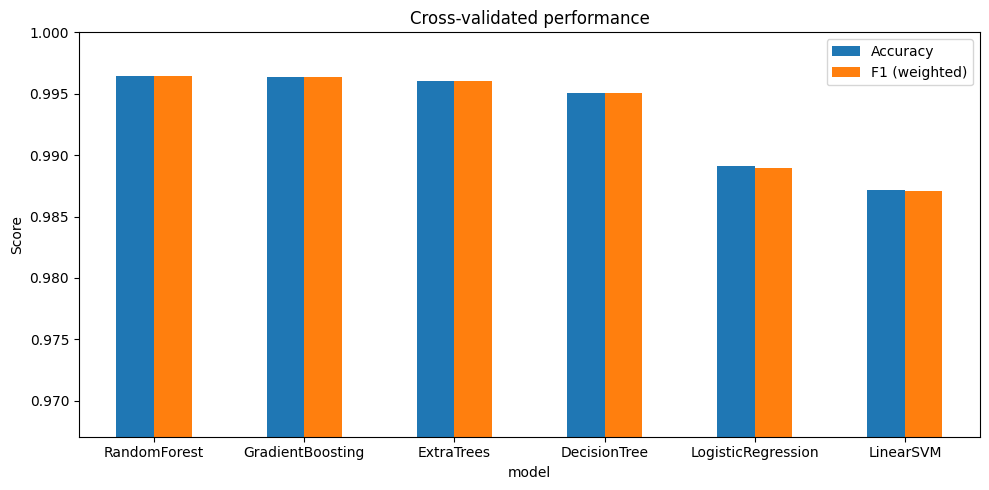

In [ ]:
ax = results_df.plot(
    x='model',
    y=['mean_accuracy', 'mean_f1_weighted'],
    kind='bar',
    figsize=(10, 5),
    rot=0,
    ylabel='Score',
    title='Cross-validated performance'
)
ax.legend(['Accuracy', 'F1 (weighted)'])
lower = max(0, min(results_df[['mean_accuracy', 'mean_f1_weighted']].min()) - 0.02)
upper = min(1, max(results_df[['mean_accuracy', 'mean_f1_weighted']].max()) + 0.01)
ax.set_ylim(lower, upper)
plt.tight_layout()
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

print("Current class distribution:")
print(Counter(y))
print(f"\nImbalance ratio: {Counter(y).most_common()[0][1] / Counter(y).most_common()[-1][1]:.2f}:1")

Current class distribution:
Counter({'DOS_SYN_Hping': 23782, 'Thing_Speak': 2009, 'ARP_poisioning': 1924, 'MQTT_Publish': 1027, 'NMAP_UDP_SCAN': 622, 'NMAP_OS_DETECTION': 488, 'NMAP_XMAS_TREE_SCAN': 480, 'NMAP_TCP_scan': 241, 'DDOS_Slowloris': 133, 'Wipro_bulb': 53, 'Metasploit_Brute_Force_SSH': 11, 'NMAP_FIN_SCAN': 9})

Imbalance ratio: 2642.44:1


In [ ]:
strategies = {
    'Baseline (no rebalancing)': None,
    'SMOTE': SMOTE(random_state=RANDOM_STATE),
    'Random Over-sampling': RandomOverSampler(random_state=RANDOM_STATE),
    'Random Under-sampling': RandomUnderSampler(random_state=RANDOM_STATE),
}

models_with_weights = {
    'LogisticRegression (balanced)': LogisticRegression(
        max_iter=400, 
        solver='lbfgs', 
        class_weight='balanced', 
        n_jobs=-1
    ),
    'RandomForest (balanced)': RandomForestClassifier(
        n_estimators=120, 
        max_depth=None, 
        class_weight='balanced', 
        n_jobs=-1, 
        random_state=RANDOM_STATE
    ),
}

In [ ]:
results_imbalanced = []
reports_imbalanced = []

base_model = RandomForestClassifier(n_estimators=120, max_depth=None, n_jobs=-1, random_state=RANDOM_STATE)

for strategy_name, sampler in strategies.items():
    if sampler is None:
        pipe = Pipeline([('preprocess', preprocess), ('model', base_model)])
    else:
        pipe = ImbPipeline([
            ('preprocess', preprocess),
            ('sampler', sampler),
            ('model', base_model)
        ])
    
    print(f"Training with {strategy_name}...")
    
    cv_pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    report_text = classification_report(y, cv_pred, digits=3)
    reports_imbalanced.append({'strategy': strategy_name, 'report': report_text})
    
    scores = cross_validate(
        pipe, X, y, cv=cv, scoring=SCORING, n_jobs=-1, return_train_score=False
    )
    
    results_imbalanced.append({
        'strategy': strategy_name,
        'mean_accuracy': scores['test_accuracy'].mean(),
        'std_accuracy': scores['test_accuracy'].std(),
        'mean_f1_weighted': scores['test_f1_weighted'].mean(),
        'std_f1_weighted': scores['test_f1_weighted'].std(),
    })

for model_name, model_balanced in models_with_weights.items():
    pipe = Pipeline([('preprocess', preprocess), ('model', model_balanced)])
    
    print(f"Training with {model_name}...")
    
    cv_pred = cross_val_predict(pipe, X, y, cv=cv, n_jobs=-1)
    report_text = classification_report(y, cv_pred, digits=3)
    reports_imbalanced.append({'strategy': model_name, 'report': report_text})
    
    scores = cross_validate(
        pipe, X, y, cv=cv, scoring=SCORING, n_jobs=-1, return_train_score=False
    )
    
    results_imbalanced.append({
        'strategy': model_name,
        'mean_accuracy': scores['test_accuracy'].mean(),
        'std_accuracy': scores['test_accuracy'].std(),
        'mean_f1_weighted': scores['test_f1_weighted'].mean(),
        'std_f1_weighted': scores['test_f1_weighted'].std(),
    })

results_imb_df = pd.DataFrame(results_imbalanced).sort_values('mean_f1_weighted', ascending=False).reset_index(drop=True)
display(results_imb_df)

print("\nClassification reports (imbalanced data strategies):")
for item in reports_imbalanced:
    print(f"\n=== {item['strategy']} ===")
    print(item['report'])

Training with Baseline (no rebalancing)...
Training with SMOTE...
Training with Random Over-sampling...
Training with Random Under-sampling...
Training with LogisticRegression (balanced)...
Training with RandomForest (balanced)...


,strategy,mean_accuracy,std_accuracy,mean_f1_weighted,std_f1_weighted
0,SMOTE,0.996719,0.000585,0.996713,0.000587
1,RandomForest (balanced),0.996654,0.000568,0.996635,0.000564
2,Random Over-sampling,0.996459,0.000528,0.996448,0.000528
3,Baseline (no rebalancing),0.996426,0.000641,0.996407,0.000632
4,LogisticRegression (balanced),0.986777,0.001462,0.987929,0.001797
5,Random Under-sampling,0.926540,0.041060,0.945229,0.030860



Classification reports (imbalanced data strategies):

=== Baseline (no rebalancing) ===
                            precision    recall  f1-score   support

            ARP_poisioning      0.972     0.986     0.979      1924
            DDOS_Slowloris      0.954     0.940     0.947       133
             DOS_SYN_Hping      1.000     1.000     1.000     23782
              MQTT_Publish      1.000     0.999     1.000      1027
Metasploit_Brute_Force_SSH      1.000     0.727     0.842        11
             NMAP_FIN_SCAN      0.778     0.778     0.778         9
         NMAP_OS_DETECTION      1.000     1.000     1.000       488
             NMAP_TCP_scan      0.996     0.996     0.996       241
             NMAP_UDP_SCAN      0.976     0.974     0.975       622
       NMAP_XMAS_TREE_SCAN      1.000     0.996     0.998       480
               Thing_Speak      0.985     0.978     0.982      2009
                Wipro_bulb      0.979     0.868     0.920        53

                  accurac

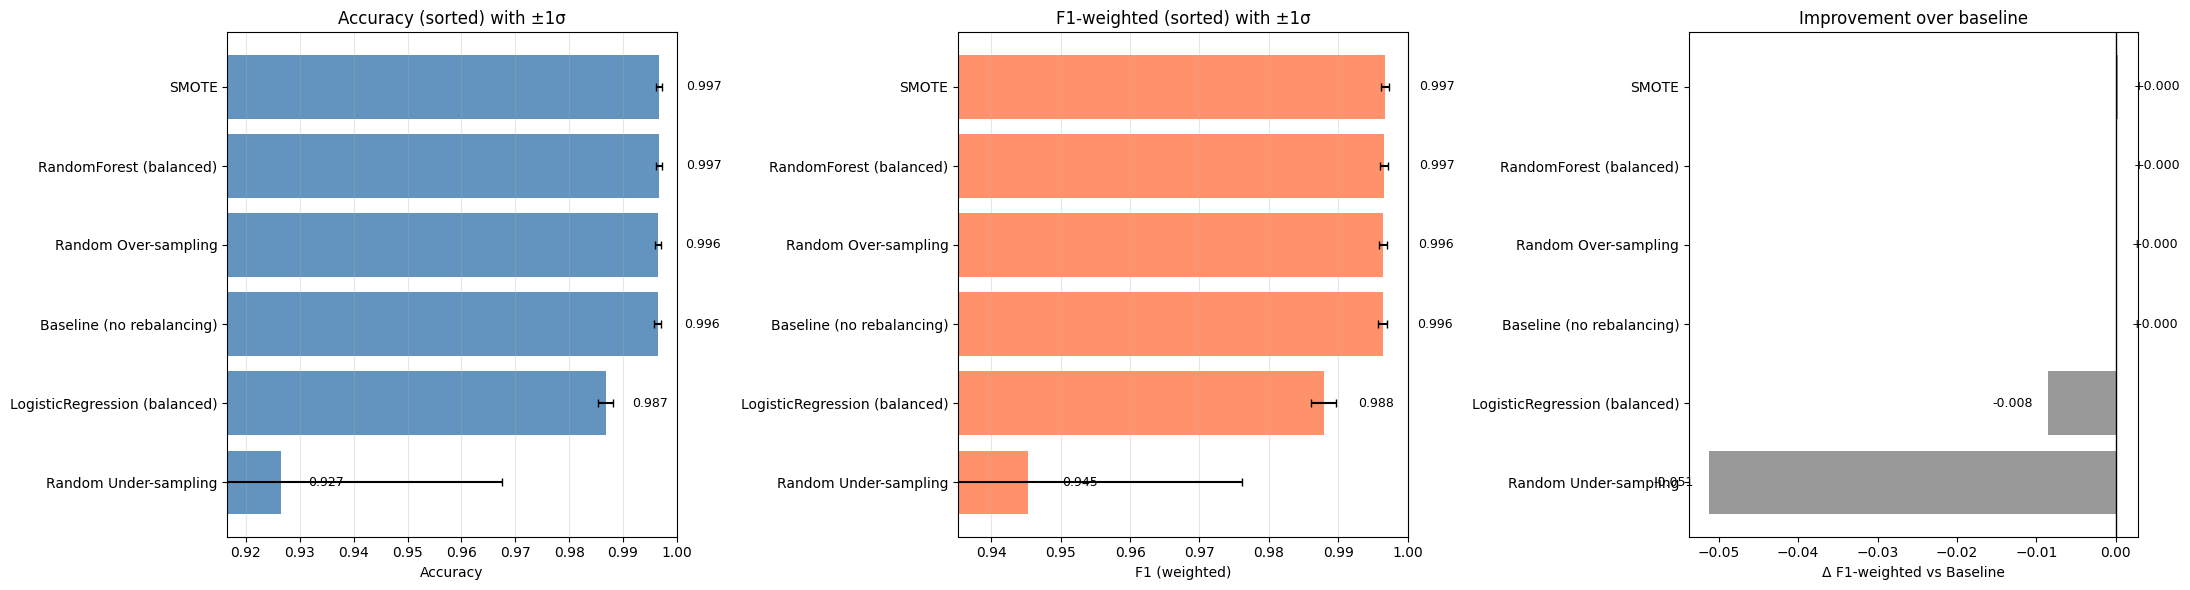

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

def annotate_bars(ax, fmt="{:.3f}"):
    for p in ax.patches:
        w = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax.text(w + 0.005, y, fmt.format(w), va='center', ha='left', fontsize=9)

acc_df = results_imb_df.sort_values('mean_accuracy')
ax1 = axes[0]
ax1.barh(
    acc_df['strategy'],
    acc_df['mean_accuracy'],
    xerr=acc_df['std_accuracy'],
    color='steelblue',
    alpha=0.85,
    capsize=3
)
ax1.set_xlabel('Accuracy')
ax1.set_title('Accuracy (sorted) with ±1σ')
acc_min = acc_df['mean_accuracy'].min()
acc_max = acc_df['mean_accuracy'].max()
ax1.set_xlim(max(0, acc_min - 0.01), min(1, acc_max + 0.01))
ax1.grid(axis='x', alpha=0.3)
annotate_bars(ax1)

f1_df = results_imb_df.sort_values('mean_f1_weighted')
ax2 = axes[1]
ax2.barh(
    f1_df['strategy'],
    f1_df['mean_f1_weighted'],
    xerr=f1_df['std_f1_weighted'],
    color='coral',
    alpha=0.85,
    capsize=3
)
ax2.set_xlabel('F1 (weighted)')
ax2.set_title('F1-weighted (sorted) with ±1σ')
f1_min = f1_df['mean_f1_weighted'].min()
f1_max = f1_df['mean_f1_weighted'].max()
ax2.set_xlim(max(0, f1_min - 0.01), min(1, f1_max + 0.01))
ax2.grid(axis='x', alpha=0.3)
annotate_bars(ax2)

ax3 = axes[2]
baseline_mask = results_imb_df['strategy'] == 'Baseline (no rebalancing)'
if baseline_mask.any():
    base_f1 = results_imb_df.loc[baseline_mask, 'mean_f1_weighted'].values[0]
    delta_f1 = results_imb_df.assign(
        delta_f1=results_imb_df['mean_f1_weighted'] - base_f1
).sort_values('delta_f1')
    ax3.barh(delta_f1['strategy'], delta_f1['delta_f1'], color='gray', alpha=0.8)
    ax3.axvline(0, color='black', linewidth=1)
    ax3.set_xlabel('Δ F1-weighted vs Baseline')
    ax3.set_title('Improvement over baseline')
    for p in ax3.patches:
        w = p.get_width()
        y = p.get_y() + p.get_height() / 2
        ax3.text(
            w + (0.002 if w >= 0 else -0.002),
            y,
            "{:+.3f}".format(w),
            va='center',
            ha=('left' if w >= 0 else 'right'),
            fontsize=9
)
else:
    ax3.text(0.5, 0.5, 'Baseline missing', ha='center', va='center', transform=ax3.transAxes)

plt.tight_layout()
plt.show()